In [176]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
g=9.81
Ts=0.005

In [177]:
class X():
    def __init__(self,state=np.zeros(6)):
        self.x,self.y,self.phi=state[0],state[1],state[2]
        self.xDot,self.yDot,self.phiDot=state[3],state[4],state[5]
    def __call__(self):
        return [self.x,self.y,self.phi,self.xDot,self.yDot,self.phiDot]




In [178]:
class Obstacle:
    def __init__(self,x,y,r):
        self.c=np.array([x,y])
        self.r=r
    def CheckCollisionThroughTime(self,state):
        nChecks=state.shape[1]
        for i in range(nChecks):
            currentState=X(state[:,i])
            if self.CheckCollision([currentState.x,currentState.y]):
                return 1
        return 0
    def CheckCollision(self,point,offset=0):
        distance=np.linalg.norm(np.array(point-self.c))
        if distance<=(self.r+offset):
            return 1
    def __call__(self):
        return self.c,self.r
    


In [179]:
from scipy.integrate import solve_ivp
goalWidth=20
XLim=800
floor=0
cieling=450

class Quadcopter:
    def __init__(self, m=0.18, L=0.086, J=1.5e-4):
        self.m, self.L, self.J = m, L, J
        self.g = 9.81
        self.state = X()

    def step(self, action, dt):
        u = np.clip(action, -1, 1)
        F = ((u[0] + 1)/2) * (1.8 * self.m * self.g)
        M = u[1] * 0.02

        s = np.array([self.state.x, self.state.y, self.state.phi, 
                      self.state.xDot, self.state.yDot, self.state.phiDot])
        
        # Dynamics
        def f(st, f_val, m_val):
            return np.array([
                st[3], st[4], st[5],
                -(f_val/self.m)*np.sin(st[2]),
                (f_val/self.m)*np.cos(st[2]) - self.g,
                m_val/self.J
            ])

        k1 = f(s, F, M)
        k2 = f(s + 0.5*dt*k1, F, M)
        k3 = f(s + 0.5*dt*k2, F, M)
        k4 = f(s + dt*k3, F, M)
        
        self.state = X(s + (dt/6)*(k1 + 2*k2 + 2*k3 + k4))

In [ ]:
from cvxopt import matrix,solvers

solvers.options['show_progress']=False

class Sigma:
    def __init__(self, k=0.02, limit=100.0):
        self.k = k
        self.limit = limit
    def val(self, s):
        return self.limit * np.tanh(self.k * s)
    def prime(self, s):
        return self.limit * self.k * (1 - np.tanh(self.k * s)**2)
    def dPrime(self, s):
        tanh_s = np.tanh(self.k * s)
        return -2 * self.limit * (self.k**2) * tanh_s * (1 - tanh_s**2)

class CBFQPController:
    def __init__(self, nominal_controller, m, J, gamma=0.8, alpha=0.8):
        self.nominal = nominal_controller 
        self.m = m
        self.J = J
        self.gamma = gamma # Lookahead horizon
        self.alpha = alpha 
        self.sigma = Sigma() 

    def cbfConstraint(self, state, lidar_dists, lidar_angles):
        G_obs, H_obs = [], []
        rSafe = 5.0 
        
        activation_dist = 200 
        
        for dist, angle in zip(lidar_dists, lidar_angles):
            if dist >= activation_dist:
                continue 
                
            rx = -dist * np.cos(angle)
            ry = -dist * np.sin(angle)
            
            s = rx * np.sin(state.phi) - ry * np.cos(state.phi)
            p = rx * np.cos(state.phi) + ry * np.sin(state.phi)
            
            v = -state.xDot * np.sin(state.phi) + state.yDot * np.cos(state.phi)
            w =  state.xDot * np.cos(state.phi) + state.yDot * np.sin(state.phi)
            
            ds = -v + p * state.phiDot 
            
            h = (rx**2 + ry**2) - rSafe**2
            hDot = 2 * (rx * state.xDot + ry * state.yDot)
            
            sig = self.sigma.val(s)
            sigP = self.sigma.prime(s)
            sigPP = self.sigma.dPrime(s)
            
            gHat = h - sig
            gHatDot = hDot - sigP * ds
            hAug = gHatDot + self.gamma * gHat
            
            C_drift = 2 * (state.xDot**2 + state.yDot**2) - 2 * 9.81 * ry
            C_sig = -sigPP * (ds**2) - sigP * (9.81 * np.cos(state.phi) + 2 * w * state.phiDot + s * (state.phiDot**2))
            C = C_drift + C_sig + self.gamma * gHatDot
            
            Lg1 = -(1 / self.m) * (2 * s - sigP)
            Lg2 = -(p * sigP) / self.J
            
            G_obs.append([-Lg1, -Lg2])
            H_obs.append(C + self.alpha * hAug)
            
        G_bounds, H_bounds = [], []
        
        # Floor
        y_floor = 15
        h_floor = state.y - y_floor
        Lg_floor = [-np.cos(state.phi) / self.m, 0]
        gamma_floor=0.4
        boundary_floor = -9.81 + 2 * gamma_floor * state.yDot + (gamma_floor**2) * h_floor
        G_bounds.append(Lg_floor)
        H_bounds.append(boundary_floor)
            
        # Ceiling
        y_ceil = 445
        h_ceil = y_ceil - state.y
        Lg_ceil = [np.cos(state.phi) / self.m, 0]
        boundary_ceil = 9.81 - 2 * gamma_floor * state.yDot + (gamma_floor**2) * h_ceil
        G_bounds.append(Lg_ceil)
        H_bounds.append(boundary_ceil)

        return np.array(G_obs), np.array(H_obs), np.array(G_bounds), np.array(H_bounds)

    def filter_action(self, u_nom, state, lidar_dists, lidar_angles):
        P = matrix(np.diag([1, 1, 1e7])) 
        q = matrix([-u_nom[0], -u_nom[1], 0])
        
        G_obs, h_obs, G_bounds, h_bounds = self.cbfConstraint(state, lidar_dists, lidar_angles)
        
        max_thrust = 1.8 * self.m * 9.81
        max_moment = 0.02
        u_max = np.array([max_thrust, max_moment])
        u_min = np.array([0, -max_moment])
        
        G_sat = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])
        h_sat = np.array([u_max[0], -u_min[0], u_max[1], -u_min[1]])

        if len(G_obs) > 0:
            slack_col = -np.ones((len(G_obs), 1))
            G_obs_cbf = np.hstack([G_obs, slack_col])
            
            no_slack_bounds = np.zeros((len(G_bounds), 1))
            G_bounds_cbf = np.hstack([G_bounds, no_slack_bounds])
            
            no_slack_sat = np.zeros((4, 1))
            G_sat_cbf = np.hstack([G_sat, no_slack_sat])
            
            G_final = matrix(np.vstack([G_obs_cbf, G_bounds_cbf, G_sat_cbf]).astype(np.float64))
            h_final = matrix(np.hstack([h_obs, h_bounds, h_sat]).astype(np.float64))
        else:
            no_slack_bounds = np.zeros((len(G_bounds), 1))
            G_bounds_cbf = np.hstack([G_bounds, no_slack_bounds])
            no_slack_sat = np.zeros((4, 1))
            G_sat_cbf = np.hstack([G_sat, no_slack_sat])
            
            G_final = matrix(np.vstack([G_bounds_cbf, G_sat_cbf]).astype(np.float64))
            h_final = matrix(np.hstack([h_bounds, h_sat]).astype(np.float64))

        try:
            sol = solvers.qp(P, q, G_final, h_final)
            if sol['status'] != 'optimal':
                raise ValueError("QP not optimal")
            
            u_safe = np.array(sol['x']).flatten()[:2]
            return u_safe
            
        except Exception:
            target_phi = np.clip(state.xDot * 0.05, -np.pi/3, np.pi/3)
            M_fallback = 0.5 * (target_phi - state.phi) - 0.1 * state.phiDot
            M_fallback = np.clip(M_fallback, -max_moment, max_moment)
            
            F_fallback = max_thrust
            
            return np.array([F_fallback, M_fallback])

In [181]:
class TimeOptimalNavEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.quad = Quadcopter()
        self.dt = 0.02
        self.max_steps = 4000

        self.bounds = np.array([0, 800, 0, 450])
        self.goal_radius = 25

        self.alpha = 10       # shaping strength
        self.R_goal = 2000
        self.R_crash = 1000

        self.n_lidar = 8

        self.action_space = spaces.Box(-1, 1, (2,), np.float32)
        self.observation_space = spaces.Box(-1, 1, (7 + self.n_lidar,), np.float32)
        
    def _get_obs(self):
        s = self.quad.state

        rel = (self.goal - np.array([s.x, s.y])) / 800
        vel = np.array([s.xDot, s.yDot]) / 10

        ang = np.array([np.sin(s.phi), np.cos(s.phi)])
        ang_vel = np.array([s.phiDot / 5])

        lidar = self._get_lidar()

        return np.concatenate([rel, vel, ang, ang_vel, lidar]).astype(np.float32)
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        # random start and goal
        self.start = np.random.uniform([10, 10], [750, 425])
        self.goal = np.random.uniform([10, 10], [750, 425])

        self.quad.state = X(np.array([self.start[0], self.start[1], 0, 0, 0, 0]))
        self.prev_dist = np.linalg.norm(self.goal - self.start)

        return self._get_obs(), {}
    def _get_lidar(self):
        return np.ones(self.n_lidar, dtype=np.float32)
    def step(self, action):
        self.steps += 1
        self.quad.step(action, self.dt)

        s = self.quad.state
        pos = np.array([s.x, s.y])
        dist = np.linalg.norm(self.goal - pos)

        # reward section
        reward = -1
        reward += self.alpha * (self.prev_dist - dist)
        self.prev_dist = dist

        terminated = False
        info = {'is_success': False} 

        # Goal reached
        if dist < self.goal_radius:
            reward += self.R_goal
            terminated = True
            info['is_success'] = True 

        # Crash check
        if not (-1 <= s.x <= 1000 and -1 <= s.y <= 450):
            reward -= self.R_crash
            terminated = True

        truncated = self.steps >= self.max_steps

        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, info

In [182]:
class TimeOptimalNavEnvNew(gym.Env):
    def __init__(self):
        super().__init__()
        self.quad = Quadcopter()
        self.dt = 0.02
        self.max_steps = 800

        self.bounds = np.array([0, 800, 0, 450])
        self.goal_radius = 25

        self.alpha = 10       # shaping strength
        self.R_goal = 2000
        self.R_crash = 1000

        self.n_lidar = 8
        self.spawn_radius = 100 
        self.max_spawn_radius = 800

        self.action_space = spaces.Box(-1, 1, (2,), np.float32)
        self.observation_space = spaces.Box(-1, 1, (7 + self.n_lidar,), np.float32)
    def _get_obs(self):
        s = self.quad.state
        dx = self.goal[0] - s.x
        dy = self.goal[1] - s.y
        
        # Rotate the global distance into the drone's local coordinate frame
        local_x = dx * np.cos(s.phi) + dy * np.sin(s.phi)
        local_y = -dx * np.sin(s.phi) + dy * np.cos(s.phi)
        rel = np.array([local_x, local_y]) / 800

        vel = np.array([s.xDot, s.yDot]) / 10
        ang = np.array([np.sin(s.phi), np.cos(s.phi)])
        ang_vel = np.array([s.phiDot / 5])

        lidar = self._get_lidar()

        return np.concatenate([rel, vel, ang, ang_vel, lidar]).astype(np.float32)
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        # random start and goal
        self.start = np.random.uniform([10, 10], [750, 425])
        angle = np.random.uniform(0, 2 * np.pi)
        dist = np.random.uniform(50, self.spawn_radius)


        goal_x = self.start[0] + dist * np.cos(angle)
        goal_y = self.start[1] + dist * np.sin(angle)
        
        # Keep goal within bounds
        goal_x = np.clip(goal_x, 50, 950)
        goal_y = np.clip(goal_y, 50, 400)
        self.goal = np.array([goal_x, goal_y])

        self.quad.state = X(np.array([self.start[0], self.start[1], 0, 0, 0, 0]))
        self.prev_dist = np.linalg.norm(self.goal - self.start)

        return self._get_obs(), {}
    def _get_lidar(self):
        return np.ones(self.n_lidar, dtype=np.float32)
    def step(self, action):
        self.steps += 1
        self.quad.step(action, self.dt)

        s = self.quad.state
        pos = np.array([s.x, s.y])
        dist = np.linalg.norm(self.goal - pos)

        # reward section
        alpha = 0.05
        reward = -self.dt + alpha * (self.prev_dist - dist)
        self.prev_dist = dist

        terminated = False
        info = {'is_success': False} 

        # Goal reached
        if dist < self.goal_radius:
            reward += self.R_goal
            terminated = True
            info['is_success'] = True 

        # Crash check
        if not (0 <= s.x <= 1000 and 0 <= s.y <= 450):
            reward -= self.R_crash
            terminated = True

        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, info

In [183]:
from stable_baselines3.common.callbacks import BaseCallback
from collections import deque
import numpy as np

class CurriculumCallback(BaseCallback):
    def __init__(self, check_freq: int, success_threshold: float = 0.8, radius_step: float = 50.0, max_radius: float = 800.0, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.success_threshold = success_threshold
        self.radius_step = radius_step
        self.max_radius = max_radius
        
        # Store the success of the last 100 episodes
        self.success_buffer = deque(maxlen=100)
        self.current_radius = 100

    def _on_step(self) -> bool:
        for idx, done in enumerate(self.locals["dones"]):
            if done:
                info = self.locals["infos"][idx]
                is_success = info.get('is_success', False)
                self.success_buffer.append(is_success)

        if self.n_calls % self.check_freq == 0 and len(self.success_buffer) >= 100:
            success_rate = np.mean(self.success_buffer)
            
            if success_rate >= self.success_threshold and self.current_radius < self.max_radius:
                self.current_radius += self.radius_step
                self.current_radius = min(self.current_radius, self.max_radius)
                
                self.training_env.env_method('set_attr', 'spawn_radius', self.current_radius)
                self.training_env.set_attr('spawn_radius', self.current_radius)
                
                if self.verbose > 0:
                    print(f"\n[Curriculum] Success rate hit {success_rate:.2f}! Increasing spawn_radius to {self.current_radius}\n")
                
                self.success_buffer.clear()
                
        return True

In [184]:
from stable_baselines3 import SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecMonitor
def make_env():
    return Monitor(TimeOptimalNavEnv())

env = make_vec_env(make_env, n_envs=16, vec_env_cls=SubprocVecEnv)

env = VecMonitor(env)

policy_kwargs = dict(
    net_arch=[256, 256]
)
curriculum_callback = CurriculumCallback(
        check_freq=1000, 
        success_threshold=0.8, 
        radius_step=100, 
        max_radius=800
    )
model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=2_000_000,
    learning_starts=25_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=64,
    gradient_steps=64,
    ent_coef="auto",          # critical for exploration
    policy_kwargs=policy_kwargs,
    verbose=1,
)

print("Training SAC time-optimal quadrotor...")
#model.learn(total_timesteps=2000000,callback=curriculum_callback)

Using cuda device
Training SAC time-optimal quadrotor...


c:\Users\Nia Touko\anaconda3\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


In [185]:
#model.save("Ciriculum-Straight-Line-Model")

In [186]:
model = model.load("Base-Straight-Line-Model")

In [187]:
'''
env=TimeOptimalNavEnv()
env = TimeOptimalNavEnv()

model=PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.0,
    clip_range=0.2,
)
model.learn(total_timesteps=400000)
    
'''


'\nenv=TimeOptimalNavEnv()\nenv = TimeOptimalNavEnv()\n\nmodel=PPO(\n    "MlpPolicy",\n    env,\n    learning_rate=3e-4,\n    n_steps=2048,\n    batch_size=256,\n    gamma=0.99,\n    gae_lambda=0.95,\n    ent_coef=0.0,\n    clip_range=0.2,\n)\nmodel.learn(total_timesteps=400000)\n    \n'

In [188]:
#model=model.load("Ciriculum-Straight-Line-Model")

In [189]:
def get_lidar(state, obstacles, n_lidar=32, max_range=200.0):
    angles = np.linspace(0, 2*np.pi, n_lidar, endpoint=False) + state.phi
    rays = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    origin = np.array([state.x, state.y])
    dists = np.full(n_lidar, max_range)
    
    with np.errstate(divide='ignore'):
        t_x0 = (0 - origin[0]) / rays[:, 0]
        t_x1 = (800 - origin[0]) / rays[:, 0]
        
    for t_vals in [t_x0, t_x1]:
        valid = (t_vals > 0) & (t_vals < max_range)
        dists[valid] = np.minimum(dists[valid], t_vals[valid])
        
    for obs in obstacles:
        oc = origin - obs.c
        b = 2 * (rays @ oc)
        c = np.dot(oc, oc) - obs.r**2
        disc = b**2 - 4*c
        
        valid = disc >= 0
        if np.any(valid):
            sqrt_disc = np.sqrt(disc[valid])
            t = (-b[valid] - sqrt_disc) / 2
            '''
            inside = t < 0
            t[inside] = 0.01
            '''
            current_dists = dists[valid]
            improve = (t > 0) & (t < current_dists) & (t < max_range)
            
            valid_indices = np.where(valid)[0]
            dists[valid_indices[improve]] = t[improve]
            
    return dists, angles

def filter_lidar(dists,angles,k=2):
    is_local_min = (dists <= np.roll(dists, 1)) & (dists < np.roll(dists, -1))
    min_indices = np.where(is_local_min)[0]
    
    if len(min_indices) == 0:
        return np.array([]), np.array([])
    sorted_min_indices = min_indices[np.argsort(dists[min_indices])]
    
    top_k_indices = sorted_min_indices[:k]
    
    return dists[top_k_indices], angles[top_k_indices]


Time Taken: 46.44 seconds


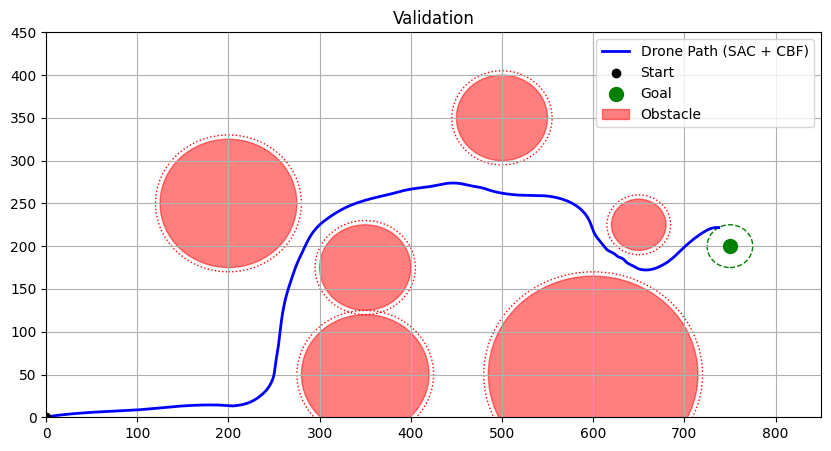

In [196]:
import matplotlib.patches as patches

env=TimeOptimalNavEnv()
cbf = CBFQPController(nominal_controller=None, m=env.quad.m, J=env.quad.J,gamma=0.91, alpha=1)
start=[0,0]
goal=[750,200]
# Define Obstacles
obstacles = [
    #Obstacle(x=350, y=250, r=40),
    #Obstacle(x=550, y=200, r=30)
    Obstacle(350,50,70),
    Obstacle(650,225,30),
    Obstacle(350,175,50),
    Obstacle(500,350,50),
    Obstacle(200,250,75),
    Obstacle(600,50,115)
]

obs, _ = env.reset()
env.quad.state = X(np.array([start[0], start[1], 0, 0, 0, 0]))
env.goal = np.array(goal)
env.prev_dist = np.linalg.norm(env.goal - np.array(start))
obs = env._get_obs()
path_x, path_y = [], []
done = False
steps = 0
m, g = env.quad.m, env.quad.g

n_lidar_rays = 32

while not done:
    action_sac, _ = model.predict(obs, deterministic=True)
    
    F_nom = ((action_sac[0] + 1) / 2) * (1.8 * m * g)
    M_nom = action_sac[1] * 0.02
    u_nom = np.array([F_nom, M_nom], dtype=np.float64)
    
    dists, angles = get_lidar(env.quad.state, obstacles, n_lidar=n_lidar_rays)
    #filt_dists, filt_angles = filter_lidar(dists, angles, k=3)
    filt_dists,filt_angles=dists,angles
    u_safe = cbf.filter_action(u_nom, env.quad.state, filt_dists, filt_angles)
    
    safe_action = np.zeros(2)
    safe_action[0] = (u_safe[0] / (1.8 * m * g)) * 2 - 1
    safe_action[1] = u_safe[1] / 0.02
    safe_action = np.clip(safe_action, -1, 1)
    
    obs, reward, done, truncated, _ = env.step(safe_action)
    done = done or truncated
    
    path_x.append(env.quad.state.x)
    path_y.append(env.quad.state.y)
    steps += 1

# Plot
time_taken = steps * env.dt 
print(f"Time Taken: {time_taken:.2f} seconds")

plt.figure(figsize=(10, 5))
plt.plot(path_x, path_y, 'b-', linewidth=2, label="Drone Path (SAC + CBF)")
plt.scatter([start[0]],[start[1]], c='k', label="Start", zorder=5)
plt.scatter([goal[0]], [goal[1]], c='g', s=100, label="Goal", zorder=5)

# Draw Goal Zone
goal_circle = plt.Circle((goal[0], goal[1]), env.goal_radius, color='g', fill=False, linestyle='--')
plt.gca().add_patch(goal_circle)

# Draw Obstacles
for obs_obj in obstacles:
    obs_circle = plt.Circle(obs_obj.c, obs_obj.r, color='r', alpha=0.5, label="Obstacle")
    safe_circle = plt.Circle(obs_obj.c, obs_obj.r + 5, color='r', fill=False, linestyle=':')
    plt.gca().add_patch(obs_circle)
    plt.gca().add_patch(safe_circle)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("Validation")
plt.xlim(0, 850)
plt.ylim(0, 450)
plt.grid(True)
plt.show()